### Autor: David Roca Tauste
---

# Análisis del perfil crediticio de clientes bancarios

Este Jupyter Notebook ha sido creado con la finalidad de que nuestro cliente (Entidad bancaria) disponga de dos modelos de predicción, con el objetivo de que sirvan de apoyo a los trabajadores para saber de manera más rápida y eficaz si conceder un préstamo o no.

Los dos modelos encargados son los siguientes:
 - Predictor de 'loan_status': determina si se ha aprueba o rechaza la solicitud del préstamo.
 - Predictor de 'risk_score': determina el riesgo crediticio del cliente.

A continuación, se encuentra el proceso de creación de ambos modelos predictores.

---
# 1. PREPARACIÓN

## 1.1. Carga de librerías

In [303]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import optuna

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, roc_auc_score

from xgboost import XGBClassifier

## 1.2. Carga del CSV y primeras observaciones de los datos

Para comenzar, vamos a realizar unas primeras observaciones de los datos.

In [304]:
ruta = "loan_data.csv"
datos = pd.read_csv(ruta)

In [305]:
print(datos.shape)
print(f"La cantidad de filas es: {datos.shape[0]}")
print(f"La cantidad de columnas es: {datos.shape[1]}")

(45000, 14)
La cantidad de filas es: 45000
La cantidad de columnas es: 14


In [306]:
datos.describe()

,age,income,yrs_exp,amount,int_rate,percent_income,cred_hist_length,risk_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,634.291556,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,366.878869,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,-637.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,77710.000000,1.000000


In [307]:
datos.head()

,age,gender,education,income,yrs_exp,ownership,amount,purpose,int_rate,percent_income,cred_hist_length,risk_score,previous_loans,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


---
# 2. LIMPIEZA DE DATOS

## 2.1. Gestión de valores nulos

Vamos a realizar una limpieza de los datos, comenzando por la búsqueda de valores nulos, debido a que estos no permiten la creación del modelo.

In [308]:
print("Número de casillas nulas:")
datos.isnull().sum()

Número de casillas nulas:


age                  0
gender               0
education            0
income               0
yrs_exp              0
ownership            0
amount               0
purpose             38
int_rate             0
percent_income       0
cred_hist_length     0
risk_score           0
previous_loans       0
loan_status          0
dtype: int64

Después de observar que hay 38 casillas nulas en la columna 'purpose', hemos llegado a la conclusión de eliminarlas porque no tendrá ningún efecto en el modelo debido a su poca cantidad.

In [309]:
datos.dropna(subset=['purpose'], inplace=True)

Comprobamos que los valores nulos se han eliminado exitosamente.

In [310]:
print("Número de casillas nulas después de la eliminación de los valores nulos:")
datos.isnull().sum()

Número de casillas nulas después de la eliminación de los valores nulos:


age                 0
gender              0
education           0
income              0
yrs_exp             0
ownership           0
amount              0
purpose             0
int_rate            0
percent_income      0
cred_hist_length    0
risk_score          0
previous_loans      0
loan_status         0
dtype: int64

## 2.2. Tipos de datos de las columnas

In [311]:
datos.dtypes

age                 float64
gender               object
education            object
income              float64
yrs_exp               int64
ownership            object
amount              float64
purpose              object
int_rate            float64
percent_income      float64
cred_hist_length    float64
risk_score            int64
previous_loans       object
loan_status           int64
dtype: object

## 2.3. Gestión de anomalías (outliers)

Otro apartado de gran importancia en la limpieza de datos es la gestión de anomalías, debido a que estas marcan la diferencia entre obtener un modelo bueno o excelente de un modelo totalmente inservible. A continuación, las vamos a tratar.

In [312]:
columnas = datos.columns.values
print(columnas)

['age' 'gender' 'education' 'income' 'yrs_exp' 'ownership' 'amount'
 'purpose' 'int_rate' 'percent_income' 'cred_hist_length' 'risk_score'
 'previous_loans' 'loan_status']


### 2.3.1 Validación de valores float

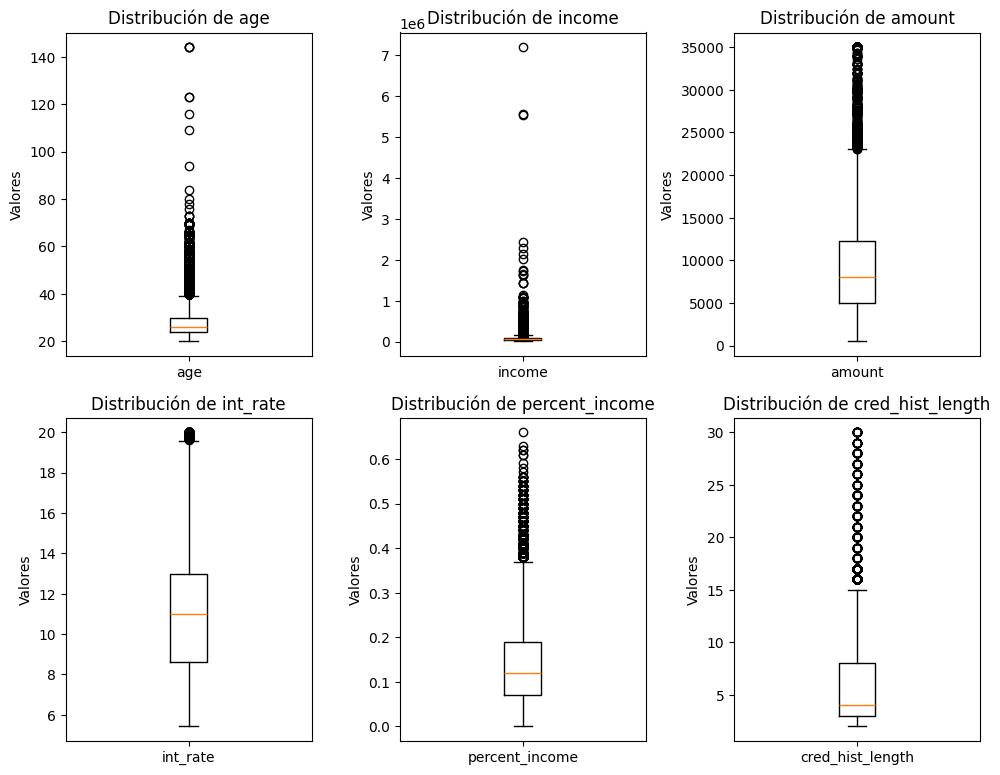

In [313]:
# Valores float
columnas_float = []

for columna_actual in columnas:
    if (datos[columna_actual].dtype == "float64"):
        columnas_float.append(columna_actual)
    

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 8))

axes = axes.flatten()
for i, var in enumerate(columnas_float):
    axes[i].boxplot(datos[var], tick_labels=[var])
    axes[i].set_title(f'Distribución de {var}')
    axes[i].set_ylabel('Valores')

for j in range(len(columnas_float), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

A partir de los boxplots que se acaban de generar, podemos observar que las columnas que más destacan son 'age' e 'income'.
 - Por un lado, se considera que los valores de 'age' mayores a 110 son erróneos y vamos a proceder con su eliminación.
 - Por otro lado, en la columna 'income', podemos obervar que, a pesar de haber una gran cantidad de outliers, hay unos pocos de que destacan del resto por ser mayores a 500000. A pesar de esto, no vamos a eliminarlos debido a que no son valores erróneos como en el caso anterior y también debido a que no hay una gran cantidad, por lo que no afectarán significativamente al modelo.

In [314]:
# Columna 'age'
valor_erroneo = 110

datos_age = datos["age"]
outliers_age = datos_age[datos_age > valor_erroneo]

print(outliers_age)

81       144.0
183      144.0
575      123.0
747      123.0
32297    144.0
37930    116.0
Name: age, dtype: float64


In [315]:
# Eliminamos los datos de clientes con más de 110 años
datos = datos[~datos['age'].isin(outliers_age)]

# Comprobamos que han sido eliminados
datos_age = datos["age"]
outliers_age = datos_age[datos_age > valor_erroneo]
print(outliers_age)

Series([], Name: age, dtype: float64)


### 2.3.2 Validación de valores integer

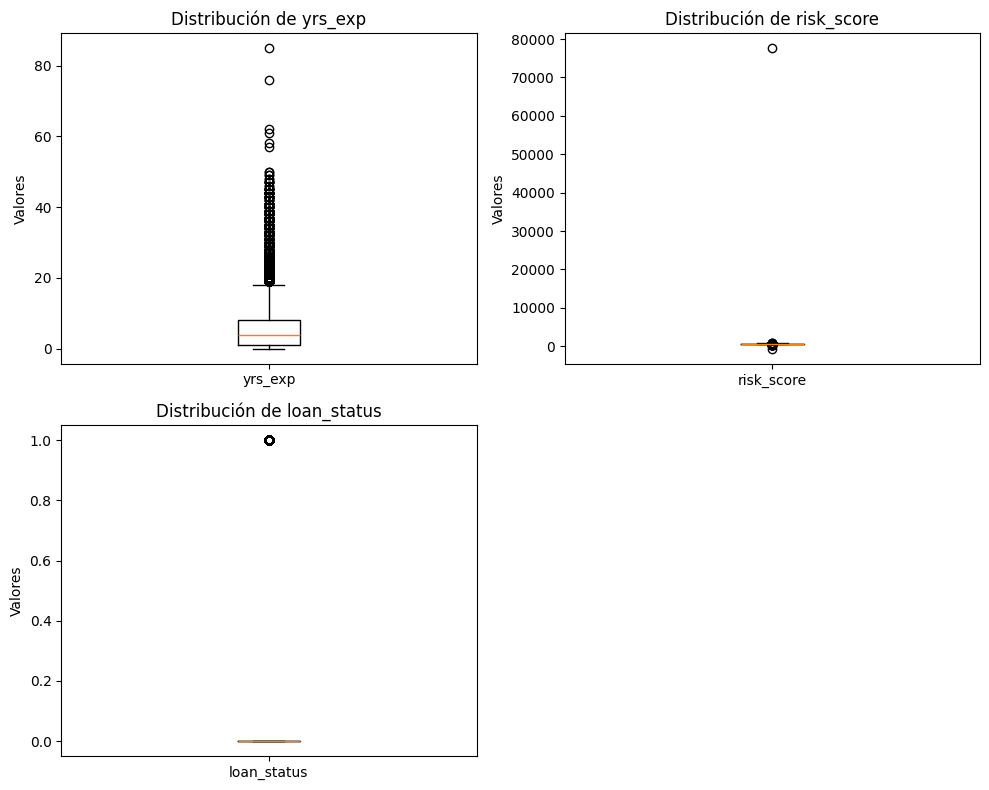

In [316]:
# Valores int
columnas_integer = []

for columna_actual in columnas:
    if (datos[columna_actual].dtype == "int64"):
        columnas_integer.append(columna_actual)
    

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

axes = axes.flatten()
for i, var in enumerate(columnas_integer):
    axes[i].boxplot(datos[var], tick_labels=[var])
    axes[i].set_title(f'Distribución de {var}')
    axes[i].set_ylabel('Valores')

for j in range(len(columnas_integer), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

A partir de los boxplots que se acaban de generar, podemos observar que hay outliers en la columna 'yrs_exp' y en la columna 'risk_score'.

In [317]:
# Columna 'yrs_exp'
valor_erroneo = 70

datos_yrs_exp = datos["yrs_exp"]
outliers_yrs_exp = datos_yrs_exp[datos_yrs_exp > valor_erroneo]

print(outliers_yrs_exp)

32416    76
38113    85
Name: yrs_exp, dtype: int64


In [318]:
# Columna 'risk_score'
valor_erroneo = 10000

datos_risk_score = datos["risk_score"]
outliers_risk_score = datos_risk_score[datos_risk_score > valor_erroneo]

print(outliers_risk_score)

9793    77710
Name: risk_score, dtype: int64


Procedemos con la eliminación de los outliers. Se han considerado como valores atípicos (o outilers) las personas con un número mayor a 70 años de experiencia y el único valor de la columna 'risk_score' que supera 70000, debido a que el resto de valores es menor que 1000.

In [319]:
# Eliminamos los datos de clientes con más de 70 años de experiencia
datos = datos[~datos['yrs_exp'].isin(outliers_yrs_exp)]

# Eliminamos los datos del cliente con un risk_score de 70000
datos = datos[~datos['risk_score'].isin(outliers_risk_score)]

Comprobamos que los outliers han sido borrados.

In [320]:
# Columna 'yrs_exp'
datos_yrs_exp = datos["yrs_exp"]
outliers_yrs_exp = datos_yrs_exp[datos_yrs_exp > 70]
print(outliers_yrs_exp)

# Columna 'risk_score'
datos_risk_score = datos["risk_score"]
outliers_risk_score = datos_risk_score[datos_risk_score > 10000]
print(outliers_risk_score)

Series([], Name: yrs_exp, dtype: int64)
Series([], Name: risk_score, dtype: int64)


### 2.3.3 Validación de valores object

En primer lugar, obtenemos las columnas de tipo objeto y, a continuación, mostraremos la cantidad de veces que se repite un valor en cada una de ellas.

In [321]:
columnas_objeto = datos.select_dtypes(include=['object']).columns

lista_columnas_objeto = list(columnas_objeto)
print(lista_columnas_objeto)

['gender', 'education', 'ownership', 'purpose', 'previous_loans']


In [322]:
for columna_actual in lista_columnas_objeto:
    conteo = datos.groupby(columna_actual).size()
    print(f"{conteo}\n")

gender
femal         1
female    20133
male      24819
dtype: int64

education
Associate      12017
Bachelor       13381
Doctorate        621
High School    11959
Master          6975
dtype: int64

ownership
MORTGAGE    18477
OTHER         117
OWN          2950
OWN             1
RENT        23408
dtype: int64

purpose
DEBTCONSOLIDATION    7132
EDUCATION            9143
HOMEIMPROVEMENT      4779
MEDICAL              8541
PERSONAL             7545
VENTURE              7813
dtype: int64

previous_loans
No     22103
Yes    22850
dtype: int64



Podemos observar que las columnas 'gender' y 'ownership' tienen un valor utilizado únicamente una vez. Por lo tanto, vamos a modificar estos valores para que se adecuen al resto de los datos.

In [323]:
# Corregimos el valor 'femal' a 'female'
datos['gender'] = datos['gender'].replace('femal', 'female')

# Verificamos que se haya corregido el valor incorrecto
print(datos['gender'].value_counts())

gender
male      24819
female    20134
Name: count, dtype: int64


In [324]:
# Limpiamos los valores de la columna 'ownership'
datos['ownership'] = datos['ownership'].str.strip()

# Verificamos que se haya realizado la limpieza correctamente
print(datos['ownership'].value_counts())

ownership
RENT        23408
MORTGAGE    18477
OWN          2951
OTHER         117
Name: count, dtype: int64


---
# 3. Ingeniería de características
## 3.1. Codificación de variables categóricas

El modelo es incapaz de clasificar los valores de tipo texto, por lo que en este apartado las vamos a convertir a entero. Para ello, utilizaremos la codificación 'One Hot' o la codificación 'Label', dependiendo de la que se adapte mejor a cada columna.

In [325]:
datos.head()

,age,gender,education,income,yrs_exp,ownership,amount,purpose,int_rate,percent_income,cred_hist_length,risk_score,previous_loans,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


Después de realizar un análisis de las columnas y sus valores de texto, hemos llegado a la conclusión de que lo más indicado es realizar una codificación:
 - 'Label' de las columna 'education' con el objetivo de mantener un orden jerárquico de los títulos.
 - 'One Hot' de las columnas 'ownership', 'purpose' y 'previous_loans' debido a que en esta ocasión no es óptimo que el modelo dé más importancia a unos valores que otros.

La codificación de la columna 'gender' se puede realizar utilizando cualquiera de las dos codificaciones, ya que no tiene ningún impacto.

In [326]:
datos['gender'] = datos['gender'].replace(["male", "female"], [0, 1])
datos['education'] = datos['education'].replace(["High School", "Associate", "Bachelor", "Master", "Doctorate"], [0, 1, 2, 3, 4])

datos = pd.get_dummies(datos, columns=['ownership'], prefix='ownership')
datos = pd.get_dummies(datos, columns=['purpose'], prefix='purpose')
datos = pd.get_dummies(datos, columns=['previous_loans'], prefix='previous_loans')

C:\Users\davil\AppData\Local\Temp\ipykernel_17732\737500548.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos['gender'] = datos['gender'].replace(["male", "female"], [0, 1])
C:\Users\davil\AppData\Local\Temp\ipykernel_17732\737500548.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos['education'] = datos['education'].replace(["High School", "Associate", "Bachelor", "Master", "Doctorate"], [0, 1, 2, 3, 4])


In [327]:
datos.head()

,age,gender,education,income,yrs_exp,amount,int_rate,percent_income,cred_hist_length,risk_score,...,ownership_OWN,ownership_RENT,purpose_DEBTCONSOLIDATION,purpose_EDUCATION,purpose_HOMEIMPROVEMENT,purpose_MEDICAL,purpose_PERSONAL,purpose_VENTURE,previous_loans_No,previous_loans_Yes
0,22.0,1,3,71948.0,0,35000.0,16.02,0.49,3.0,561,...,False,True,False,False,False,False,True,False,True,False
1,21.0,1,0,12282.0,0,1000.0,11.14,0.08,2.0,504,...,True,False,False,True,False,False,False,False,False,True
2,25.0,1,0,12438.0,3,5500.0,12.87,0.44,3.0,635,...,False,False,False,False,False,True,False,False,True,False
3,23.0,1,2,79753.0,0,35000.0,15.23,0.44,2.0,675,...,False,True,False,False,False,True,False,False,True,False
4,24.0,0,3,66135.0,1,35000.0,14.27,0.53,4.0,586,...,False,True,False,False,False,True,False,False,True,False


Al comprobar que las codificaciones se han realizado, observamos que hay una columna que es innecesaria, ya sea 'previous_loans_No' o 'previous_loans_Yes', por lo que decidimos borrar una de ellas. También aprovechamos para comprobar que el tipo de las columnas ha sido modificado.

In [328]:
datos.drop('previous_loans_No', axis=1, inplace=True)

datos.dtypes

age                          float64
gender                         int64
education                      int64
income                       float64
yrs_exp                        int64
amount                       float64
int_rate                     float64
percent_income               float64
cred_hist_length             float64
risk_score                     int64
loan_status                    int64
ownership_MORTGAGE              bool
ownership_OTHER                 bool
ownership_OWN                   bool
ownership_RENT                  bool
purpose_DEBTCONSOLIDATION       bool
purpose_EDUCATION               bool
purpose_HOMEIMPROVEMENT         bool
purpose_MEDICAL                 bool
purpose_PERSONAL                bool
purpose_VENTURE                 bool
previous_loans_Yes              bool
dtype: object

---
# MODELO 1. PREDICTOR DE: LOAN STATUS

En este apartado vamos a realizar el desarrollo del primer modelo solicitado por la empresa. Este se encargará de predecir si se aprueba la propuesta de préstamo o no.

### 3.2. Selección de características

Para comenzar, vamos a realizar un mapa de calor para conocer que columnas tienen una baja relación con nuestro objetivo 'loan_status', para de esta manera prescindir de ellas y que el modelo sea más preciso.

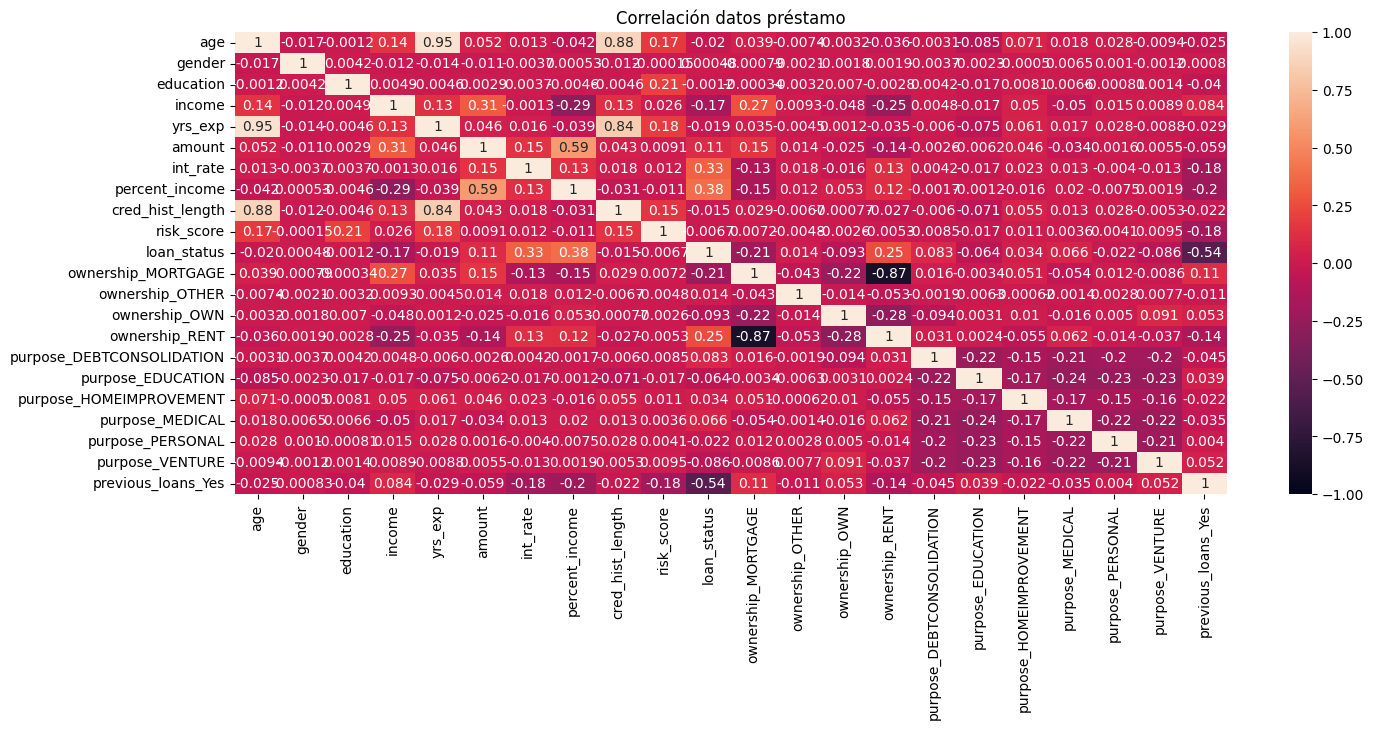

In [329]:
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(datos.corr(), vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlación datos préstamo')

plt.show()

In [330]:
valor_objetivo = "loan_status"
print(datos.shape)
print(datos[valor_objetivo].describe())
datos.describe()

(44953, 22)
count    44953.000000
mean         0.221743
std          0.415424
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: loan_status, dtype: float64


,age,gender,education,income,yrs_exp,amount,int_rate,percent_income,cred_hist_length,risk_score,loan_status
count,44953.000000,44953.000000,44953.000000,4.495300e+04,44953.000000,44953.000000,44953.000000,44953.000000,44953.000000,44953.000000,44953.000000
mean,27.747781,0.447890,1.383400,7.992440e+04,5.394101,9582.898049,11.005161,0.139700,5.866194,632.562610,0.221743
std,5.903090,0.497283,1.077826,6.333701e+04,5.919362,6314.384137,2.979064,0.087182,3.876819,50.749077,0.415424
min,20.000000,0.000000,0.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,-637.000000,0.000000
25%,24.000000,0.000000,0.000000,4.721900e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,0.000000,1.000000,6.704900e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,1.000000,2.000000,9.578900e+04,8.000000,12231.000000,12.990000,0.190000,8.000000,670.000000,0.000000
max,84.000000,1.000000,4.000000,2.448661e+06,62.000000,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000


Una vez que hemos estudiado el mapa de calor, hemos llegado a la conclusión de que las columnas más relevantes son: 'previous_loans_Yes', 'percent_income', 'int_rate', 'ownership_RENT' y 'ownership_MORTGAGE'. Por lo tanto, vamos a eliminar todas las demás con el objetivo de que el modelo sea lo más preciso posible.

In [331]:
columnas_relevantes = ['previous_loans_Yes', 'percent_income', 'int_rate', 'ownership_RENT', 'ownership_MORTGAGE']
datos_loan_status = datos[columnas_relevantes + [valor_objetivo]]
datos_loan_status.head()

,previous_loans_Yes,percent_income,int_rate,ownership_RENT,ownership_MORTGAGE,loan_status
0,False,0.49,16.02,True,False,1
1,True,0.08,11.14,False,False,0
2,False,0.44,12.87,False,True,1
3,False,0.44,15.23,True,False,1
4,False,0.53,14.27,True,False,1


### 3.3. Escalado

Escalamos las columnas que contienen valores numéricos para que la distancia entre estos sea la menor posible.

In [332]:
datos_loan_status["percent_income"] = (
    datos_loan_status["percent_income"] - datos_loan_status["percent_income"].mean()
) / datos_loan_status["percent_income"].std()

datos_loan_status["int_rate"] = (
    datos_loan_status["int_rate"] - datos_loan_status["int_rate"].mean()
) / datos_loan_status["int_rate"].std()

C:\Users\davil\AppData\Local\Temp\ipykernel_17732\1606379479.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datos_loan_status["percent_income"] = (
C:\Users\davil\AppData\Local\Temp\ipykernel_17732\1606379479.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datos_loan_status["int_rate"] = (


In [333]:
datos_loan_status.head()

,previous_loans_Yes,percent_income,int_rate,ownership_RENT,ownership_MORTGAGE,loan_status
0,False,4.018031,1.683361,True,False,1
1,True,-0.684770,0.045262,False,False,0
2,False,3.444519,0.625982,False,True,1
3,False,3.444519,1.418177,True,False,1
4,False,4.476841,1.095928,True,False,1


## 4. Análisis exploratorio de datos

Realizamos un análisis de los datos para comprobar si estos están distribuidos correctamente.

Text(0.5, 1.0, 'Distribución de valores de loan_status')

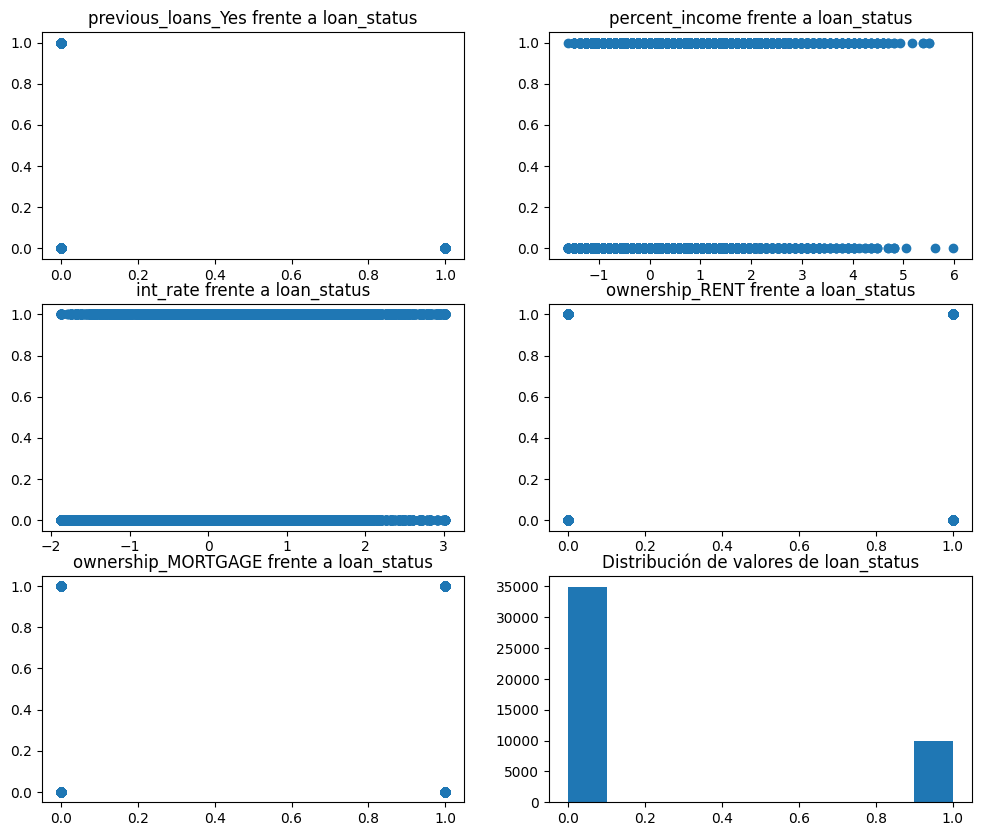

In [334]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))

for i in range(0, len(columnas_relevantes)):
    fila = i // 2
    columna = i % 2
    ax[fila, columna].scatter(x = datos_loan_status[columnas_relevantes[i]], y = datos_loan_status[valor_objetivo])
    ax[fila, columna].set_title(columnas_relevantes[i] + " frente a " + valor_objetivo)
    
ax[2, 1].hist(datos_loan_status[valor_objetivo], bins=10)
ax[2, 1].set_title("Distribución de valores de " + valor_objetivo)

## 5. Desarrollo de un modelo supervisado de clasificación
Desarrollamos el primer modelo solicitado.

### 5.1. Elección del modelo
Para comenzar, vamos a realizar una curva AUC-ROC para conocer cual es el modelo más indicado para este caso.

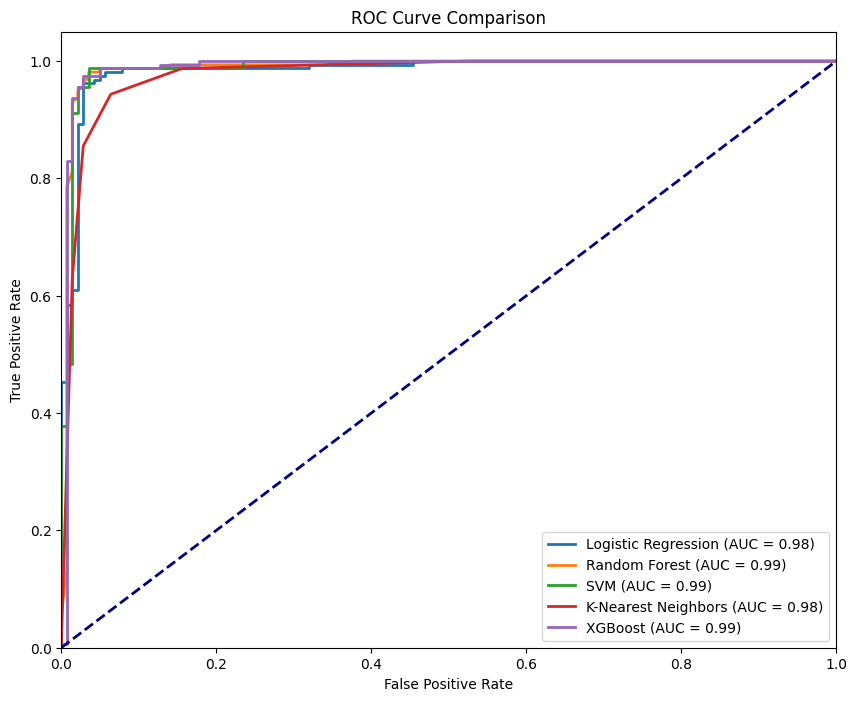

Logistic Regression: AUC - ROC = 0.98
Random Forest: AUC - ROC = 0.99
SVM: AUC - ROC = 0.99
K-Nearest Neighbors: AUC - ROC = 0.98
XGBoost: AUC - ROC = 0.99


In [335]:
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "XGBoost": XGBClassifier()
}

roc_auc_scores = {}
plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_probs = model.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_probs)
    roc_auc_scores[name] = roc_auc
    
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Especificamos las características del gráfico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.show()

for name, score in roc_auc_scores.items():
    print(f'{name}: AUC - ROC = {score:.2f}')

Después de visualizar el gráfico, hemos decidido realizar el entrenamiento del modelo con `Random Forest` y `XGBoost`, debido a que ambos han obtenido un AUC de 0'99.

### 5.2. Preparación de los conjuntos train y test

Dividimos el conjunto de datos en 'train' y 'test' para, posteriormente, realizar el entrenamiento del modelo.

In [336]:
X = datos_loan_status.drop('loan_status',axis=1)
y = datos_loan_status['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

### 5.3. Entrenamiento y métricas de validación del modelo

Entrenamos el modelo `RandomForestClassifier` y `XGBoost` e imprimimos sus métricas para conocer como de buenos han sido sus resultados.

In [337]:
def train_validation(model):
    model.fit(X_train, y_train.astype(int))
    y_pred = model.predict(X_test)
    conf_matrix = confusion_matrix(y_pred, y_test)

    print(classification_report(y_pred, y_test.astype(int)))
    print("score_test = ", model.score(X_test, y_test.astype(int)))
    print("score_train = ", model.score(X_train, y_train.astype(int)))

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No préstamo", "Préstamo"],
        yticklabels=["No préstamo", "Préstamo"],
    )
    plt.title("Matriz de Confusión")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

              precision    recall  f1-score   support

           0       0.94      0.92      0.93      5396
           1       0.70      0.76      0.73      1347

    accuracy                           0.89      6743
   macro avg       0.82      0.84      0.83      6743
weighted avg       0.89      0.89      0.89      6743

score_test =  0.8866973157348361
score_train =  0.9592776760010469


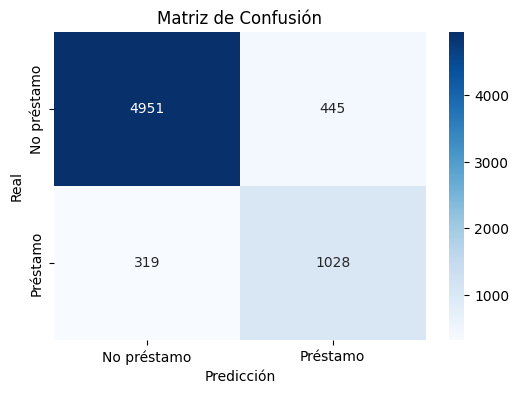

In [338]:
# Modelo 1: RandomForestClassifier
model = RandomForestClassifier(random_state=42, n_estimators=100)
train_validation(model)

#### 5.3.1 Tuning de hiperparámetros

Antes de entrenar el segundo modelo, realizamos un tuning de hiperparámetros para intentar obtener los mejores hiperparámetros para su entrenamiento.

In [353]:
def objective(trial):
    max_depth = trial.suggest_int('max_depth', 3, 15)
    learning_rate = trial.suggest_float('learning_rate', 0.005, 0.7, log=True)
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    gamma = trial.suggest_float('gamma', 0.0, 1.0)

    model = XGBClassifier(max_depth=max_depth, learning_rate=learning_rate, n_estimators=n_estimators, gamma=gamma)
    return cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()

# Crear el studio y ver los resultados
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40)
print("Mejores hiperparámetros:", study.best_params)

[I 2025-01-14 20:36:01,417] A new study created in memory with name: no-name-b29d4895-6ed9-44de-a6d9-26575346f274
[I 2025-01-14 20:36:05,812] Trial 0 finished with value: 0.8992672075372938 and parameters: {'max_depth': 12, 'learning_rate': 0.013616512286377318, 'n_estimators': 461, 'gamma': 0.7318097185588551}. Best is trial 0 with value: 0.8992672075372938.
[I 2025-01-14 20:36:06,630] Trial 1 finished with value: 0.8985082439152056 and parameters: {'max_depth': 13, 'learning_rate': 0.3892687909925778, 'n_estimators': 310, 'gamma': 0.8750823055351166}. Best is trial 0 with value: 0.8992672075372938.
[I 2025-01-14 20:36:14,955] Trial 2 finished with value: 0.8986652708714995 and parameters: {'max_depth': 13, 'learning_rate': 0.007551581938551255, 'n_estimators': 326, 'gamma': 0.510106833479255}. Best is trial 0 with value: 0.8992672075372938.
[I 2025-01-14 20:36:17,510] Trial 3 finished with value: 0.8993980633342057 and parameters: {'max_depth': 14, 'learning_rate': 0.0990392182801633

Mejores hiperparámetros: {'max_depth': 5, 'learning_rate': 0.3754805244624729, 'n_estimators': 499, 'gamma': 0.0740769777700299}


              precision    recall  f1-score   support

           0       0.96      0.92      0.94      5537
           1       0.69      0.84      0.75      1206

    accuracy                           0.90      6743
   macro avg       0.82      0.88      0.85      6743
weighted avg       0.91      0.90      0.91      6743

score_test =  0.9025656236096693
score_train =  0.9092122481025909


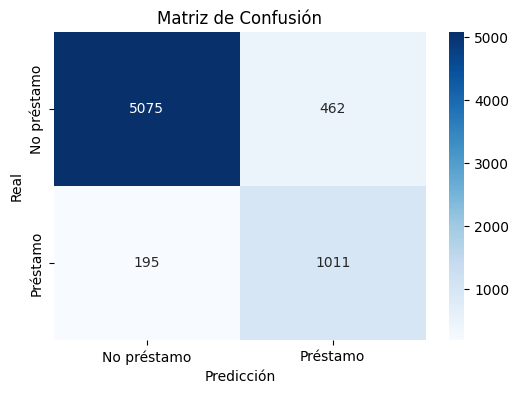

In [354]:
# Modelo 2: XGBClassifier
model = XGBClassifier(
    max_depth=study.best_params['max_depth'],
    learning_rate=study.best_params['learning_rate'],
    n_estimators=study.best_params['n_estimators'],
    gamma=study.best_params['gamma']
)

model.fit(X_train, y_train)
train_validation(model)

Tras haber entrenado los dos modelos, hemos llegado a la conclusión de quedarnos el entrenado con `XGBoost`, debido a que ha sido el que ha obtenido mejores resultados en el apartado de test. En el intento actual ha obtenido (sobre 1) un `0.9025` y en su mejor intento `0.9051`.

## 6. Predicción ficticia para la prueba del modelo

Finalmente, realizamos unas pruebas del modelo a partir de unos clientes ficticios para comprobar su rendimiento.

In [341]:
datos_cliente_prueba = {
    'previous_loans_Yes': [False],
    'percent_income': [2.74],
    'int_rate': [0.89],
    'ownership_RENT': [True],
    'ownership_MORTGAGE': [False]
}

datos_cliente_prueba2 = {
    'previous_loans_Yes': [True],
    'percent_income': [1.79],
    'int_rate': [0.13],
    'ownership_RENT': [True],
    'ownership_MORTGAGE': [True]
}

datos_prueba = pd.DataFrame(datos_cliente_prueba)
datos_prueba2 = pd.DataFrame(datos_cliente_prueba2)

datos_prueba3 = datos[1234:1235]
datos_prueba3_relevantes = datos_prueba3[columnas_relevantes]
resultado_original = "Sí" if datos_prueba3["loan_status"].values == [1] else "No"

prediccion = model.predict(datos_prueba)
prediccion2 = model.predict(datos_prueba2)
prediccion3 = model.predict(datos_prueba3_relevantes)

prediccion = "Sí" if prediccion == 1 else "No"
prediccion2 = "Sí" if prediccion == 1 else "No"
prediccion3 = "Sí" if prediccion == 1 else "No"

print(f"¿Se aprueba el préstamo del cliente 1?: {prediccion}")
print(f"¿Se aprueba el préstamo del cliente 2?: {prediccion2}")
print(f"¿Se aprueba el préstamo del cliente 3?: {prediccion3}. Resultado original: {resultado_original}")

¿Se aprueba el préstamo del cliente 1?: Sí
¿Se aprueba el préstamo del cliente 2?: No
¿Se aprueba el préstamo del cliente 3?: No. Resultado original: No


---
# MODELO 2. PREDICTOR DE: RISK SCORE

En este apartado vamos a realizar el desarrollo del segundo modelo solicitado por la empresa. Este se encargará de predecir la posibilidad de que el cliente no devuelva el préstamo.

### 3.2. Selección de características

Para comenzar, vamos a realizar un mapa de calor para conocer que columnas tienen una baja relación con nuestro objetivo 'risk_score', para de esta manera prescindir de ellas y que el modelo sea más preciso.

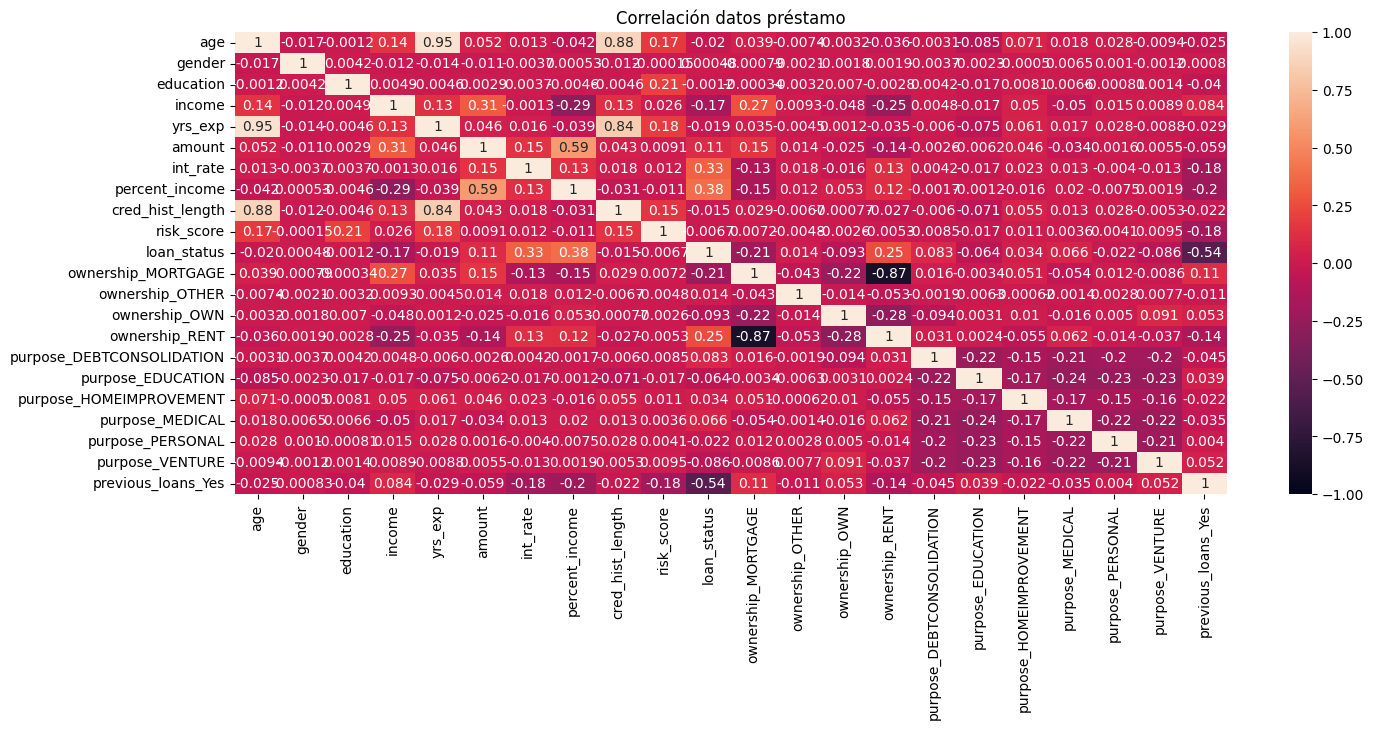

In [342]:
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(datos.corr(), vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlación datos préstamo')

plt.show()

In [343]:
valor_objetivo = "risk_score"
print(datos.shape)
print(datos[valor_objetivo].describe())
datos.describe()

(44953, 22)
count    44953.000000
mean       632.562610
std         50.749077
min       -637.000000
25%        601.000000
50%        640.000000
75%        670.000000
max        784.000000
Name: risk_score, dtype: float64


,age,gender,education,income,yrs_exp,amount,int_rate,percent_income,cred_hist_length,risk_score,loan_status
count,44953.000000,44953.000000,44953.000000,4.495300e+04,44953.000000,44953.000000,44953.000000,44953.000000,44953.000000,44953.000000,44953.000000
mean,27.747781,0.447890,1.383400,7.992440e+04,5.394101,9582.898049,11.005161,0.139700,5.866194,632.562610,0.221743
std,5.903090,0.497283,1.077826,6.333701e+04,5.919362,6314.384137,2.979064,0.087182,3.876819,50.749077,0.415424
min,20.000000,0.000000,0.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,-637.000000,0.000000
25%,24.000000,0.000000,0.000000,4.721900e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,0.000000,1.000000,6.704900e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,1.000000,2.000000,9.578900e+04,8.000000,12231.000000,12.990000,0.190000,8.000000,670.000000,0.000000
max,84.000000,1.000000,4.000000,2.448661e+06,62.000000,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000


Una vez que hemos estudiado el mapa de calor, hemos llegado a la conclusión de que las columnas más relevantes son: 'education', 'previous_loans_Yes', 'yrs_exp', 'age' y 'cred_hist_length'. Por lo tanto, vamos a eliminar todas las demás con el objetivo de que el modelo sea lo más preciso posible.

In [344]:
columnas_relevantes = ['education', 'previous_loans_Yes', 'yrs_exp', 'age', 'cred_hist_length']
datos_risk_score = datos[columnas_relevantes + [valor_objetivo]]
datos_risk_score.head()

,education,previous_loans_Yes,yrs_exp,age,cred_hist_length,risk_score
0,3,False,0,22.0,3.0,561
1,0,True,0,21.0,2.0,504
2,0,False,3,25.0,3.0,635
3,2,False,0,23.0,2.0,675
4,3,False,1,24.0,4.0,586


### 3.3. Escalado

Escalamos las columnas que contienen valores numéricos para que la distancia entre estos sea la menor posible.

In [345]:
datos_risk_score["education"] = (
    datos_risk_score["education"] - datos_risk_score["education"].mean()
) / datos_risk_score["education"].std()

datos_risk_score["yrs_exp"] = (
    datos_risk_score["yrs_exp"] - datos_risk_score["yrs_exp"].mean()
) / datos_risk_score["yrs_exp"].std()

datos_risk_score["age"] = (
    datos_risk_score["age"] - datos_risk_score["age"].mean()
) / datos_risk_score["age"].std()

datos_risk_score["cred_hist_length"] = (
    datos_risk_score["cred_hist_length"] - datos_risk_score["cred_hist_length"].mean()
) / datos_risk_score["cred_hist_length"].std()

C:\Users\davil\AppData\Local\Temp\ipykernel_17732\699950827.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datos_risk_score["education"] = (
C:\Users\davil\AppData\Local\Temp\ipykernel_17732\699950827.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datos_risk_score["yrs_exp"] = (
C:\Users\davil\AppData\Local\Temp\ipykernel_17732\699950827.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the

In [346]:
datos_risk_score.head()

,education,previous_loans_Yes,yrs_exp,age,cred_hist_length,risk_score
0,1.499871,False,-0.911264,-0.973690,-0.739316,561
1,-1.283511,True,-0.911264,-1.143093,-0.997259,504
2,-1.283511,False,-0.404452,-0.465482,-0.739316,635
3,0.572077,False,-0.911264,-0.804287,-0.997259,675
4,1.499871,False,-0.742327,-0.634885,-0.481372,586


## 4. Análisis exploratorio de datos

Realizamos un análisis de los datos para comprobar si estos están distribuidos correctamente.

Text(0.5, 1.0, 'Distribución de valores de risk_score')

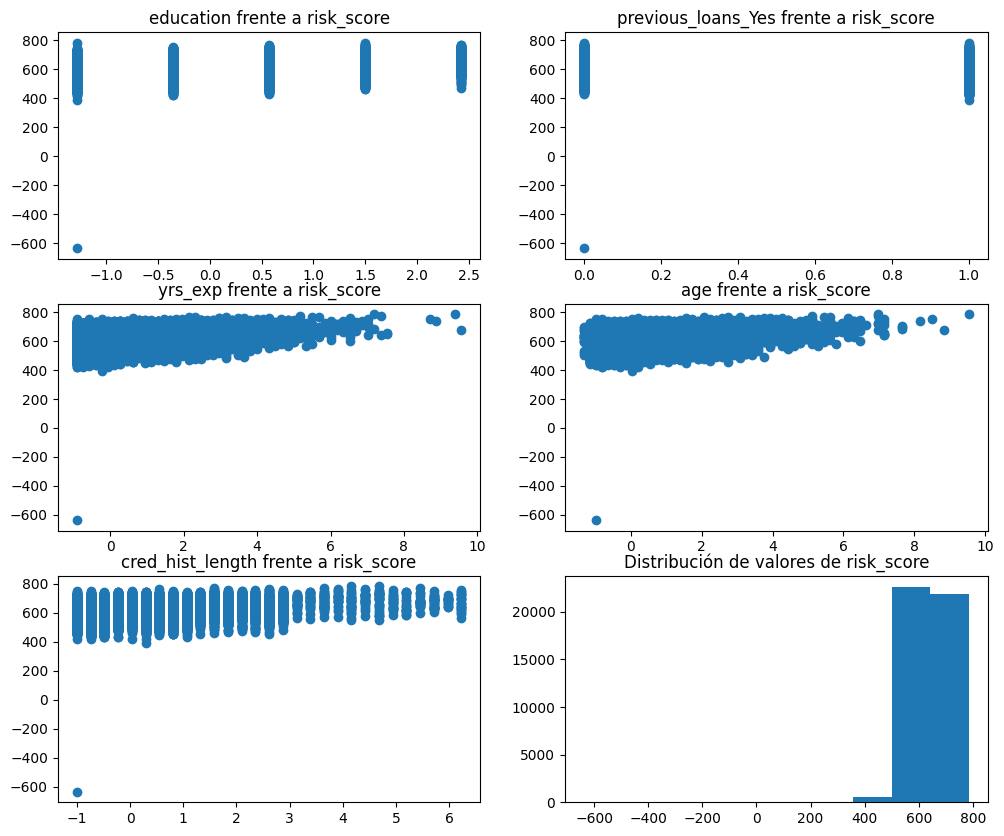

In [347]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))

for i in range(0, len(columnas_relevantes)):
    fila = i // 2
    columna = i % 2
    ax[fila, columna].scatter(x = datos_risk_score[columnas_relevantes[i]], y = datos_risk_score[valor_objetivo])
    ax[fila, columna].set_title(columnas_relevantes[i] + " frente a " + valor_objetivo)
    
ax[2, 1].hist(datos_risk_score[valor_objetivo], bins=10)
ax[2, 1].set_title("Distribución de valores de " + valor_objetivo)

## 5. Desarrollo de un modelo supervisado de regresión
Desarrollamos el segundo modelo solicitado. Para ello, vamos a utlizar un árbol de decisión (DecisionTreeRegressor).

### 5.1. Definición de la métrica

In [348]:
def metrica(valores_reales, valores_predichos):
    return mean_absolute_error(valores_reales, valores_predichos)

### 5.2. Definición de conjuntos de entrenamiento y test

Dividimos el conjunto de datos en 'train' y 'test' para, posteriormente, realizar el entrenamiento del modelo.

In [349]:
df_train, df_val = train_test_split(datos_risk_score, test_size=0.2, random_state=12)

### 5.3. Definición del modelo

Entrenamos el modelo e imprimimos la métrica que ha obtenido para los datos de validación. Para ello, vamos a utilizar un árbol de decisión (DecisionTreeRegressor), debido a su sencillez y velocidad.

In [350]:
modelo_arbol = DecisionTreeRegressor(random_state=12, max_depth=6, min_samples_split=10)
modelo_arbol.fit(df_train[columnas_relevantes], df_train[valor_objetivo])

predicciones = modelo_arbol.predict(df_val[columnas_relevantes])
error_val = metrica(df_val[valor_objetivo], predicciones)

print(f'Métrica para datos de validación: {error_val}')

Métrica para datos de validación: 38.53944129038783


## 6. Métricas de validación de modelos de regresión
Imprimimos más métricas del modelo para conocer más ampliamente la eficaz del mismo.

In [351]:
y_true = df_val[valor_objetivo]
y_pred = predicciones

# Error Absoluto Medio (MAE - Mean Absolute Error)
mae = mean_absolute_error(y_true, y_pred)
print(f"MAE: {mae}")

# Error Cuadrático Medio (MSE - Mean Squared Error)
mse = mean_squared_error(y_true, y_pred)
print(f"MSE: {mse}")

# Raíz del Error Cuadrático Medio (RMSE)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse}")

# Coeficiente de Determinación (R²)
r2 = r2_score(y_true, y_pred)
print(f"R2: {r2}")

MAE: 38.53944129038783
MSE: 2467.5001623754615
RMSE: 49.673938462492195
R2: 0.09465590090933251


Después de haber realizado varios modelos, estas han sido las mejores métricas que hemos podido obtener. Su `Error Absoluto Medio` (MAE) es: `38'54`

## 7. Predicción ficticia para la prueba del modelo

Finalmente, realizamos unas pruebas del modelo a partir de unos clientes ficticios para comprobar su rendimiento.

In [352]:
datos_cliente_prueba = {
    'education': [3],
    'previous_loans_Yes': [False],
    'yrs_exp': [6],
    'age': 31.0,
    'cred_hist_length': [20]
}

datos_cliente_prueba2 = {
    'education': [0],
    'previous_loans_Yes': [True],
    'yrs_exp': [1],
    'age': 21.0,
    'cred_hist_length': [40]
}

datos_prueba = pd.DataFrame(datos_cliente_prueba)
datos_prueba2 = pd.DataFrame(datos_cliente_prueba2)

datos_prueba3 = datos[1234:1235]
datos_prueba3_relevantes = datos_prueba3[columnas_relevantes]
resultado_original = datos_prueba3["risk_score"].values

prediccion = modelo_arbol.predict(datos_prueba)
prediccion2 = modelo_arbol.predict(datos_prueba2)
prediccion3 = modelo_arbol.predict(datos_prueba3_relevantes)

print(f"¿Cuál es el riesgo de que el cliente 1 no devuelva el préstamo?: {prediccion.round(2)}")
print(f"¿Cuál es el riesgo de que el cliente 2 no devuelva el préstamo?: {prediccion2.round(2)}")
print(f"¿Cuál es el riesgo de que el cliente 3 no devuelva el préstamo?: {prediccion3.round(2)}. Resultado original: {resultado_original}")

¿Cuál es el riesgo de que el cliente 1 no devuelva el préstamo?: [670.6]
¿Cuál es el riesgo de que el cliente 2 no devuelva el préstamo?: [784.]
¿Cuál es el riesgo de que el cliente 3 no devuelva el préstamo?: [671.33]. Resultado original: [653]
